# 🍎🍊🍌 Fruit Quality Grading
## Step 2: CNN Training with EfficientNetB0

This notebook trains a **Convolutional Neural Network** on the labeled dataset produced by Step 1 (K-Means clustering) to classify fresh fruit images into quality grades.

### Pipeline
```
output/labeled_dataset.csv  (from Step 1)
           ↓
  Load & verify labels
           ↓
  Train / Validation / Test split (stratified)
           ↓
  Data augmentation
           ↓
  EfficientNetB0 (pretrained ImageNet)
    Phase 1: Train top classifier only
    Phase 2: Fine-tune full network
           ↓
  Evaluate — Accuracy, F1, Confusion Matrix
           ↓
  Grad-CAM visualizations
           ↓
  Save model → output/models/fruit_grader.keras
```

### Output Classes (9 total)
`apple_A` · `apple_B` · `apple_C` · `orange_A` · `orange_B` · `orange_C` · `banana_A` · `banana_B` · `banana_C`

## 📦 1. Install Dependencies

In [1]:
!pip install tensorflow scikit-learn pandas matplotlib seaborn opencv-python tqdm -q
print("All dependencies installed")

All dependencies installed



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📚 2. Imports

In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")

# Check GPU
gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {'Yes — ' + gpus[0].name if gpus else 'No (using CPU)'}")

TensorFlow version : 2.16.1
GPU available      : No (using CPU)


## ⚙️ 3. Configuration

> Make sure `LABELED_CSV` points to the `labeled_dataset.csv` produced by Step 1.

In [3]:
# ─────────────────────────────────────────────
#  CONFIGURATION
# ─────────────────────────────────────────────

LABELED_CSV   = "output/labeled_dataset.csv"  # from Step 1
OUTPUT_DIR    = "output"
MODEL_DIR     = "output/models"
LOG_DIR       = "output/logs"

IMAGE_SIZE    = (224, 224)
BATCH_SIZE    = 32
RANDOM_STATE  = 42

# Training phases
PHASE1_EPOCHS = 15    # train top classifier only (base frozen)
PHASE2_EPOCHS = 30    # fine-tune full network

PHASE1_LR     = 1e-3
PHASE2_LR     = 1e-4

# Split ratios
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
TEST_RATIO    = 0.15   # remaining

# Class names (9 total)
FRUITS = ["apple", "orange", "banana"]
GRADES = ["A", "B", "C"]
CLASS_NAMES = [f"{f}_{g}" for f in FRUITS for g in GRADES]

for d in [MODEL_DIR, LOG_DIR, f"{OUTPUT_DIR}/plots", f"{OUTPUT_DIR}/gradcam"]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f"Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")
print(f"Image size : {IMAGE_SIZE}")
print(f"Batch size : {BATCH_SIZE}")

Classes (9): ['apple_A', 'apple_B', 'apple_C', 'orange_A', 'orange_B', 'orange_C', 'banana_A', 'banana_B', 'banana_C']
Image size : (224, 224)
Batch size : 32


## 📂 4. Load & Verify Labeled Dataset

In [4]:
df = pd.read_csv(LABELED_CSV)

# Verify all image files exist
df["exists"] = df["image_path"].apply(lambda p: Path(p).exists())
missing = df[~df["exists"]]
if len(missing) > 0:
    print(f"WARNING: {len(missing)} image paths not found — dropping them.")
    df = df[df["exists"]].copy()

df = df.reset_index(drop=True)

print(f"Total images loaded : {len(df):,}")
print(f"Columns             : {list(df.columns)}")
print(f"\nLabel distribution:")
dist = df["label"].value_counts().sort_index()
for label, count in dist.items():
    bar = chr(9608) * (count // 30)
    print(f"  {label:12s}  {count:>5,}  {bar}")

Total images loaded : 5,904
Columns             : ['image_path', 'fruit', 'cluster_id', 'grade', 'label', 'exists']

Label distribution:
  apple_A         670  ██████████████████████
  apple_B         773  █████████████████████████
  apple_C         645  █████████████████████
  banana_A        558  ██████████████████
  banana_B      1,095  ████████████████████████████████████
  banana_C        309  ██████████
  orange_A        558  ██████████████████
  orange_B      1,173  ███████████████████████████████████████
  orange_C        123  ████


## 📊 5. Class Distribution Chart

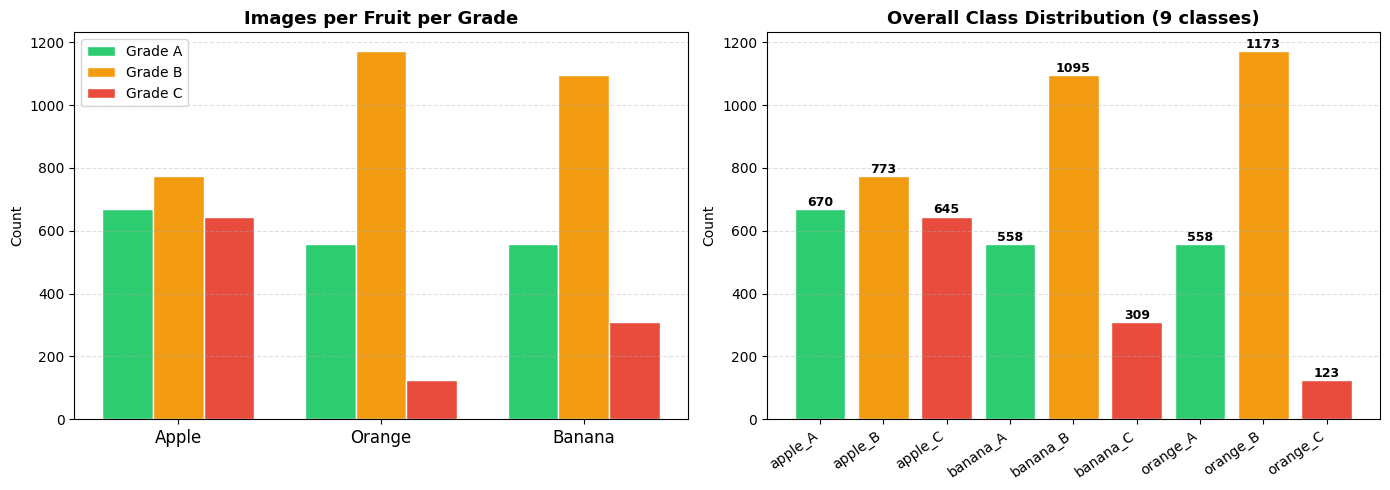

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
grade_colors = {"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c"}

# Per fruit per grade
fruits = df["fruit"].unique()
x = np.arange(len(fruits))
width = 0.25
for i, grade in enumerate(GRADES):
    counts = [len(df[(df["fruit"] == f) & (df["grade"] == grade)]) for f in fruits]
    axes[0].bar(x + i * width, counts, width,
                label=f"Grade {grade}", color=grade_colors[grade], edgecolor="white")
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([f.capitalize() for f in fruits], fontsize=12)
axes[0].set_title("Images per Fruit per Grade", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, axis="y", linestyle="--", alpha=0.4)

# Overall
overall = df["label"].value_counts().sort_index()
bar_colors = [grade_colors[lbl.split("_")[1]] for lbl in overall.index]
axes[1].bar(range(len(overall)), overall.values, color=bar_colors, edgecolor="white")
axes[1].set_xticks(range(len(overall)))
axes[1].set_xticklabels(overall.index, rotation=35, ha="right", fontsize=10)
axes[1].set_title("Overall Class Distribution (9 classes)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.4)
for i, v in enumerate(overall.values):
    axes[1].text(i, v + 10, str(v), ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## ✂️ 6. Train / Validation / Test Split

Stratified split ensures each of the 9 classes is proportionally represented in all three sets.

In [6]:
# First split: train vs (val + test)
df_train, df_temp = train_test_split(
    df, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df["label"], random_state=RANDOM_STATE
)

# Second split: val vs test
val_fraction = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
df_val, df_test = train_test_split(
    df_temp, test_size=(1 - val_fraction),
    stratify=df_temp["label"], random_state=RANDOM_STATE
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train set : {len(df_train):,} images ({len(df_train)/len(df)*100:.0f}%)")
print(f"Val set   : {len(df_val):,} images ({len(df_val)/len(df)*100:.0f}%)")
print(f"Test set  : {len(df_test):,} images ({len(df_test)/len(df)*100:.0f}%)")
print(f"\nClass balance check (train):")
for label, count in df_train["label"].value_counts().sort_index().items():
    print(f"  {label:12s} {count:>5,}")

Train set : 4,132 images (70%)
Val set   : 886 images (15%)
Test set  : 886 images (15%)

Class balance check (train):
  apple_A        469
  apple_B        541
  apple_C        451
  banana_A       391
  banana_B       766
  banana_C       216
  orange_A       391
  orange_B       821
  orange_C        86


## 🔄 7. Data Pipeline & Augmentation

Training images are augmented to improve generalization. Validation and test images are only normalized.

In [8]:
# Encode string labels to integers
le = LabelEncoder()
le.fit(CLASS_NAMES)

def encode_labels(df_split):
    return le.transform(df_split["label"].values)

# Label arrays
y_train = encode_labels(df_train)
y_val   = encode_labels(df_val)
y_test  = encode_labels(df_test)

NUM_CLASSES = len(le.classes_)
print(f"Number of classes : {NUM_CLASSES}")
print(f"Label mapping     : {dict(zip(le.classes_, le.transform(le.classes_)))}")


def load_and_preprocess(path, augment=False):
    """Load image, resize, normalize, and optionally augment."""
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE)
    img = img.astype(np.float32) / 255.0

    if augment:
        # Random horizontal flip
        if np.random.rand() > 0.5:
            img = np.fliplr(img)
        # Random brightness jitter
        factor = np.random.uniform(0.8, 1.2)
        img = np.clip(img * factor, 0, 1)
        # Random rotation (-15 to +15 degrees)
        angle = np.random.uniform(-15, 15)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h))

    return img


def make_dataset(df_split, labels, augment=False, shuffle=False):
    """Build a tf.data.Dataset from a DataFrame."""
    paths  = df_split["image_path"].values
    y_onehot = tf.keras.utils.to_categorical(labels, NUM_CLASSES)

    def generator():
        indices = np.arange(len(paths))
        if shuffle:
            np.random.shuffle(indices)
        for i in indices:
            img = load_and_preprocess(paths[i], augment=augment)
            yield img, y_onehot[i]

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(*IMAGE_SIZE, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(NUM_CLASSES,),   dtype=tf.float32),
        )
    )
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(df_train, y_train, augment=True,  shuffle=True)
val_ds   = make_dataset(df_val,   y_val,   augment=False, shuffle=False)
test_ds  = make_dataset(df_test,  y_test,  augment=False, shuffle=False)

print("Datasets created:")
print(f"  train_ds : {len(df_train):,} images in {len(list(train_ds))} batches")
print(f"  val_ds   : {len(df_val):,} images in {len(list(val_ds))} batches")
print(f"  test_ds  : {len(df_test):,} images in {len(list(test_ds))} batches")

Number of classes : 9
Label mapping     : {'apple_A': 0, 'apple_B': 1, 'apple_C': 2, 'banana_A': 3, 'banana_B': 4, 'banana_C': 5, 'orange_A': 6, 'orange_B': 7, 'orange_C': 8}
Datasets created:
  train_ds : 4,132 images in 130 batches
  val_ds   : 886 images in 28 batches
  test_ds  : 886 images in 28 batches


## 🖼️ 8. Preview Training Samples

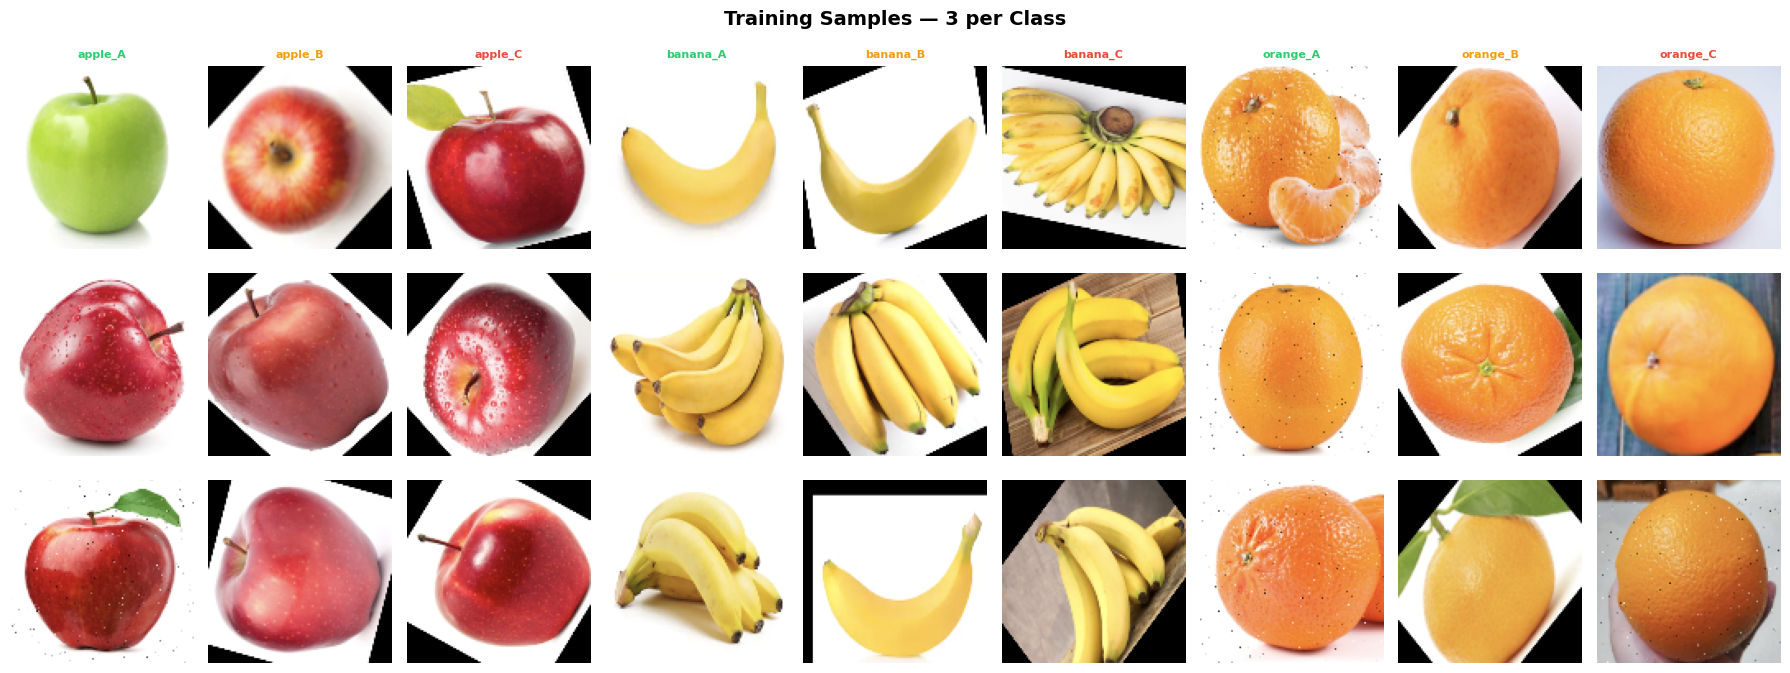

In [9]:
fig, axes = plt.subplots(3, 9, figsize=(18, 7))
grade_colors = {"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c"}

for col, class_name in enumerate(sorted(CLASS_NAMES)):
    subset = df_train[df_train["label"] == class_name]
    samples = subset.sample(min(3, len(subset)), random_state=RANDOM_STATE)
    fruit, grade = class_name.split("_")

    for row, (_, sample) in enumerate(samples.iterrows()):
        ax = axes[row, col]
        img = cv2.imread(sample["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (112, 112))
        ax.imshow(img)
        ax.axis("off")
        if row == 0:
            ax.set_title(class_name, fontsize=8, fontweight="bold",
                         color=grade_colors[grade])

plt.suptitle("Training Samples — 3 per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/training_samples.png", dpi=120, bbox_inches="tight")
plt.show()

## 🧠 9. Build the Model — EfficientNetB0

We use **transfer learning**: the EfficientNetB0 backbone (pretrained on ImageNet) is used as a feature extractor, and we add a custom classification head on top.

**Phase 1** — base is frozen, only the head is trained (fast convergence).  
**Phase 2** — entire network is unfrozen and fine-tuned at a low learning rate.

In [10]:
def build_model(num_classes, learning_rate=PHASE1_LR, freeze_base=True):
    """Build EfficientNetB0-based fruit grading model."""
    # Base model
    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMAGE_SIZE, 3),
    )
    base.trainable = not freeze_base

    # Classification head
    inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
    x = base(inputs, training=not freeze_base)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy",
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")],
    )
    return model


model = build_model(NUM_CLASSES, freeze_base=True)
model.summary()

total_params     = model.count_params()
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,964 (16.73 MB)

 Trainable params: 333,321 (1.27 MB)

 Non-trainable params: 4,052,643 (15.46 MB)


Total params     : 4,385,964
Trainable params : 333,321


## 🏋️ 10. Phase 1 Training — Frozen Base

Train only the classification head while the EfficientNetB0 base is frozen.

In [11]:
callbacks_phase1 = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(f"{MODEL_DIR}/best_phase1.keras", monitor="val_accuracy",
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
]

print("Phase 1: Training classification head (base frozen)...")
print(f"Epochs: {PHASE1_EPOCHS} | LR: {PHASE1_LR}\n")

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks_phase1,
    verbose=1,
)

print(f"\nBest val accuracy (Phase 1): {max(history1.history['val_accuracy']):.4f}")

Phase 1: Training classification head (base frozen)...
Epochs: 15 | LR: 0.001

Epoch 1/15
    130/Unknown 59s 374ms/step - accuracy: 0.1453 - loss: 2.7816 - precision: 0.1812 - recall: 0.0415
Epoch 1: val_accuracy improved from None to 0.19865, saving model to output/models/best_phase1.keras

Epoch 1: finished saving model to output/models/best_phase1.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 73s 483ms/step - accuracy: 0.1496 - loss: 2.5863 - precision: 0.1807 - recall: 0.0295 - val_accuracy: 0.1986 - val_loss: 2.1051 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/15
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.1524 - loss: 2.4162 - precision: 0.1462 - recall: 0.0180
Epoch 2: val_accuracy did not improve from 0.19865
130/130 ━━━━━━━━━━━━━━━━━━━━ 61s 469ms/step - accuracy: 0.1658 - loss: 2.3816 - precision: 0.1627 - recall: 0.0182 - val_accuracy: 0.1986 - val_loss: 2.0942 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0

## 🔥 11. Phase 2 Fine-Tuning — Full Network

Unfreeze the entire network and train with a much lower learning rate.

In [12]:
# Unfreeze base model
for layer in model.layers:
    layer.trainable = True

# Recompile with lower LR
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=PHASE2_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy",
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall")],
)

callbacks_phase2 = [
    EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint(f"{MODEL_DIR}/fruit_grader.keras", monitor="val_accuracy",
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4, verbose=1),
]

print("Phase 2: Fine-tuning full network...")
print(f"Epochs: {PHASE2_EPOCHS} | LR: {PHASE2_LR}\n")

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_phase2,
    verbose=1,
)

print(f"\nBest val accuracy (Phase 2): {max(history2.history['val_accuracy']):.4f}")
print(f"Model saved -> {MODEL_DIR}/fruit_grader.keras")

Phase 2: Fine-tuning full network...
Epochs: 30 | LR: 0.0001

Epoch 1/30
    130/Unknown 305s 2s/step - accuracy: 0.4395 - loss: 1.6677 - precision: 0.5760 - recall: 0.2751
Epoch 1: val_accuracy improved from None to 0.18397, saving model to output/models/fruit_grader.keras

Epoch 1: finished saving model to output/models/fruit_grader.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.6142 - loss: 1.1596 - precision: 0.7612 - recall: 0.4743 - val_accuracy: 0.1840 - val_loss: 2.2138 - val_precision: 0.8966 - val_recall: 0.0293 - learning_rate: 1.0000e-04
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8371 - loss: 0.5058 - precision: 0.8786 - recall: 0.7956
Epoch 2: val_accuracy improved from 0.18397 to 0.18623, saving model to output/models/fruit_grader.keras

Epoch 2: finished saving model to output/models/fruit_grader.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.8633 - loss: 0.4367 - precision: 0.8968 - recall: 0.8265 - val_accuracy: 0.186

## 📈 12. Training Curves

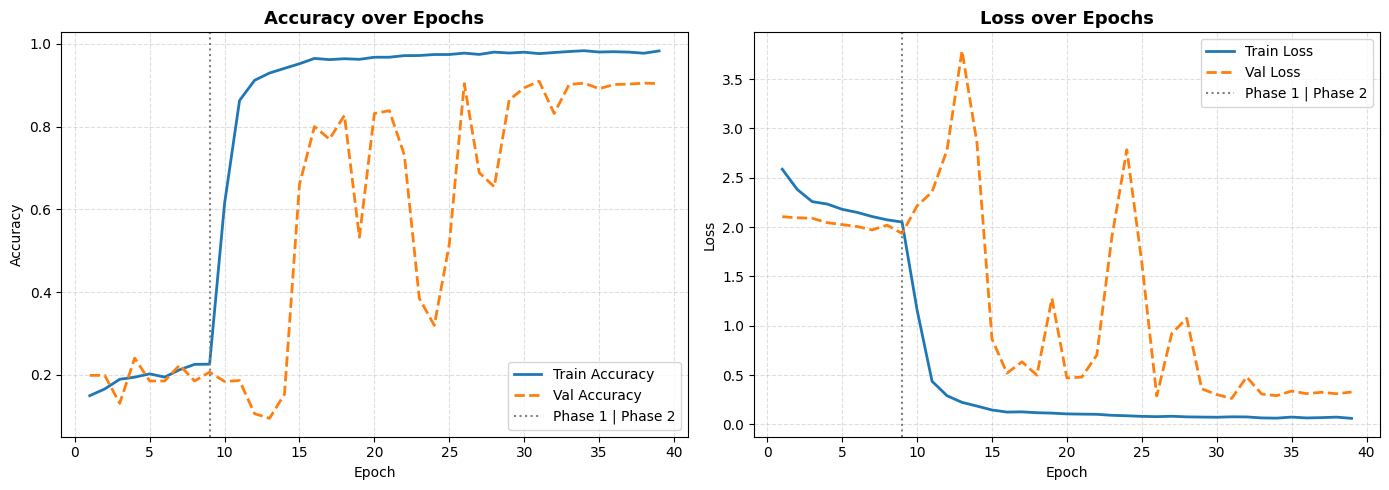

In [13]:
def merge_histories(h1, h2):
    """Concatenate Phase 1 + Phase 2 history dicts."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

history = merge_histories(history1, history2)
phase1_len = len(history1.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(
    axes,
    [("accuracy", "val_accuracy"), ("loss", "val_loss")],
    ["Accuracy", "Loss"]
):
    train_key, val_key = metric
    epochs = range(1, len(history[train_key]) + 1)
    ax.plot(epochs, history[train_key], label=f"Train {title}", linewidth=2)
    ax.plot(epochs, history[val_key],   label=f"Val {title}",   linewidth=2, linestyle="--")
    ax.axvline(x=phase1_len, color="gray", linestyle=":", linewidth=1.5, label="Phase 1 | Phase 2")
    ax.set_title(f"{title} over Epochs", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 🎯 13. Evaluation on Test Set

In [14]:
print("Evaluating on test set...")

# Load best saved model
best_model = keras.models.load_model(f"{MODEL_DIR}/fruit_grader.keras")

# Get predictions
y_pred_probs = best_model.predict(test_ds, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = y_test

# Metrics
test_loss, test_acc, test_prec, test_rec = best_model.evaluate(test_ds, verbose=0)
f1 = f1_score(y_true, y_pred, average="macro")

print(f"\n{'='*45}")
print(f"  TEST SET RESULTS")
print(f"{'='*45}")
print(f"  Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Precision : {test_prec:.4f}")
print(f"  Recall    : {test_rec:.4f}")
print(f"  F1-Score  : {f1:.4f}  (macro)")
print(f"{'='*45}")

Evaluating on test set...

  TEST SET RESULTS
  Accuracy  : 0.9052  (90.52%)
  Precision : 0.9124
  Recall    : 0.9052
  F1-Score  : 0.8927  (macro)


## 📋 14. Per-Class Classification Report

In [15]:
target_names = le.classes_
report = classification_report(y_true, y_pred, target_names=target_names)
print(report)

# Save report
with open(f"{OUTPUT_DIR}/classification_report.txt", "w") as f:
    f.write(report)
print("Saved -> output/classification_report.txt")

              precision    recall  f1-score   support

     apple_A       0.75      1.00      0.86       100
     apple_B       0.99      0.80      0.89       116
     apple_C       0.97      0.86      0.91        97
    banana_A       0.86      1.00      0.92        83
    banana_B       0.99      0.92      0.95       165
    banana_C       0.96      0.94      0.95        47
    orange_A       0.80      1.00      0.89        84
    orange_B       0.99      0.84      0.91       176
    orange_C       0.67      0.89      0.76        18

    accuracy                           0.91       886
   macro avg       0.89      0.92      0.89       886
weighted avg       0.92      0.91      0.91       886

Saved -> output/classification_report.txt


## 🔢 15. Confusion Matrix

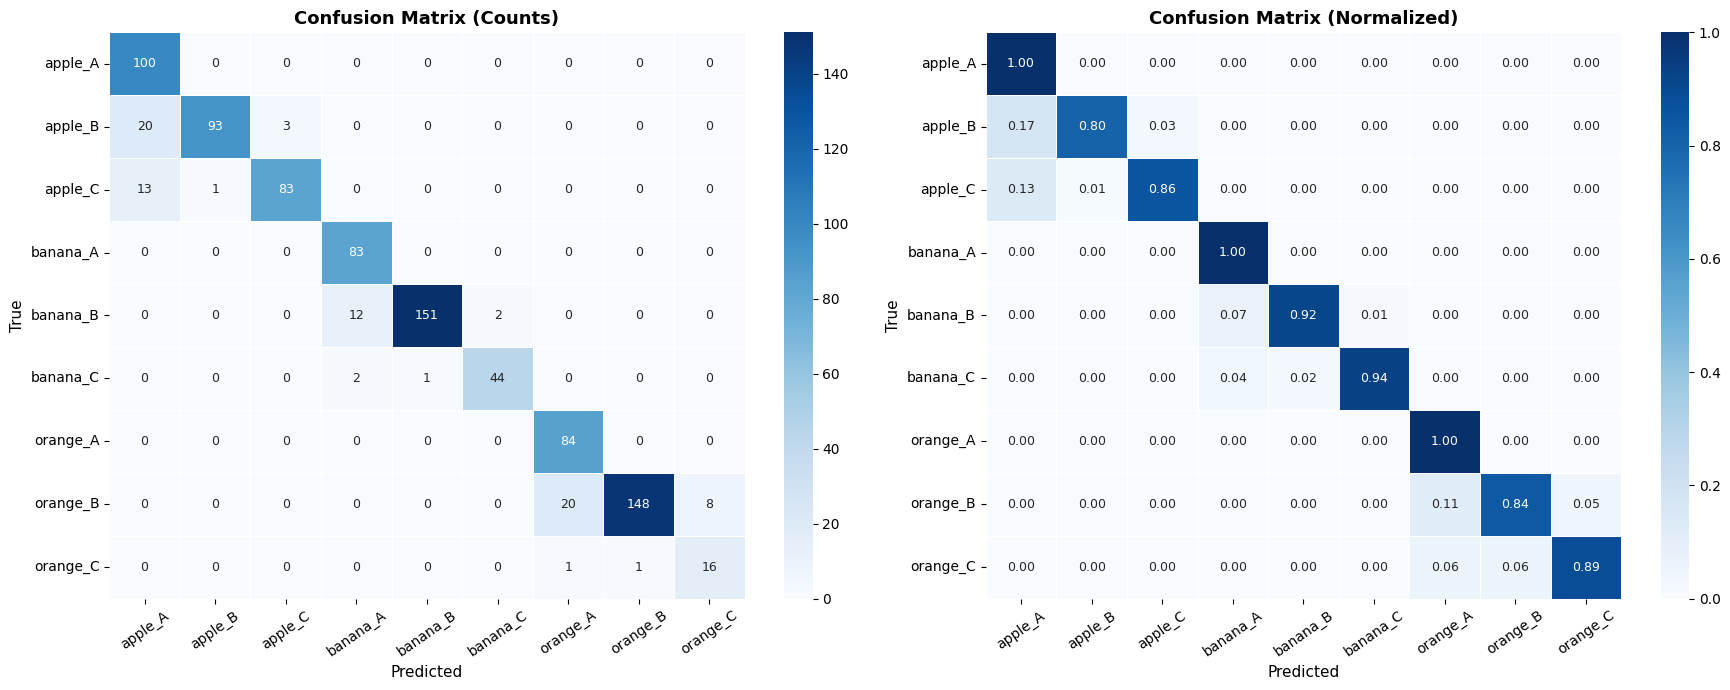

In [16]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalized

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ["d", ".2f"],
    ["Confusion Matrix (Counts)", "Confusion Matrix (Normalized)"]
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=target_names, yticklabels=target_names,
        ax=ax, linewidths=0.5, linecolor="white",
        annot_kws={"size": 9},
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 🔥 16. Grad-CAM Visualizations

Grad-CAM highlights **which region of the fruit** the model focuses on when predicting its grade. This is very useful for your report — it shows the model is looking at meaningful areas (surface texture, color spots) rather than background.

In [17]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv"):
    """Generate Grad-CAM heatmap for a single image."""
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), predictions.numpy()


def overlay_gradcam(img_path, heatmap, alpha=0.4):
    """Overlay heatmap on original image."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE)

    heatmap_resized = cv2.resize(heatmap, IMAGE_SIZE)
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    overlay = (img * (1 - alpha) + heatmap_colored * alpha).astype(np.uint8)
    return img, overlay


# Find the last conv layer name in EfficientNetB0
last_conv_layer = None
for layer in best_model.layers:
    if isinstance(layer, keras.Model):  # the EfficientNetB0 sub-model
        for sub_layer in layer.layers:
            if isinstance(sub_layer, layers.Conv2D):
                last_conv_layer = sub_layer.name
if last_conv_layer is None:
    last_conv_layer = "top_conv"
print(f"Last conv layer for Grad-CAM: {last_conv_layer}")

Last conv layer for Grad-CAM: top_conv


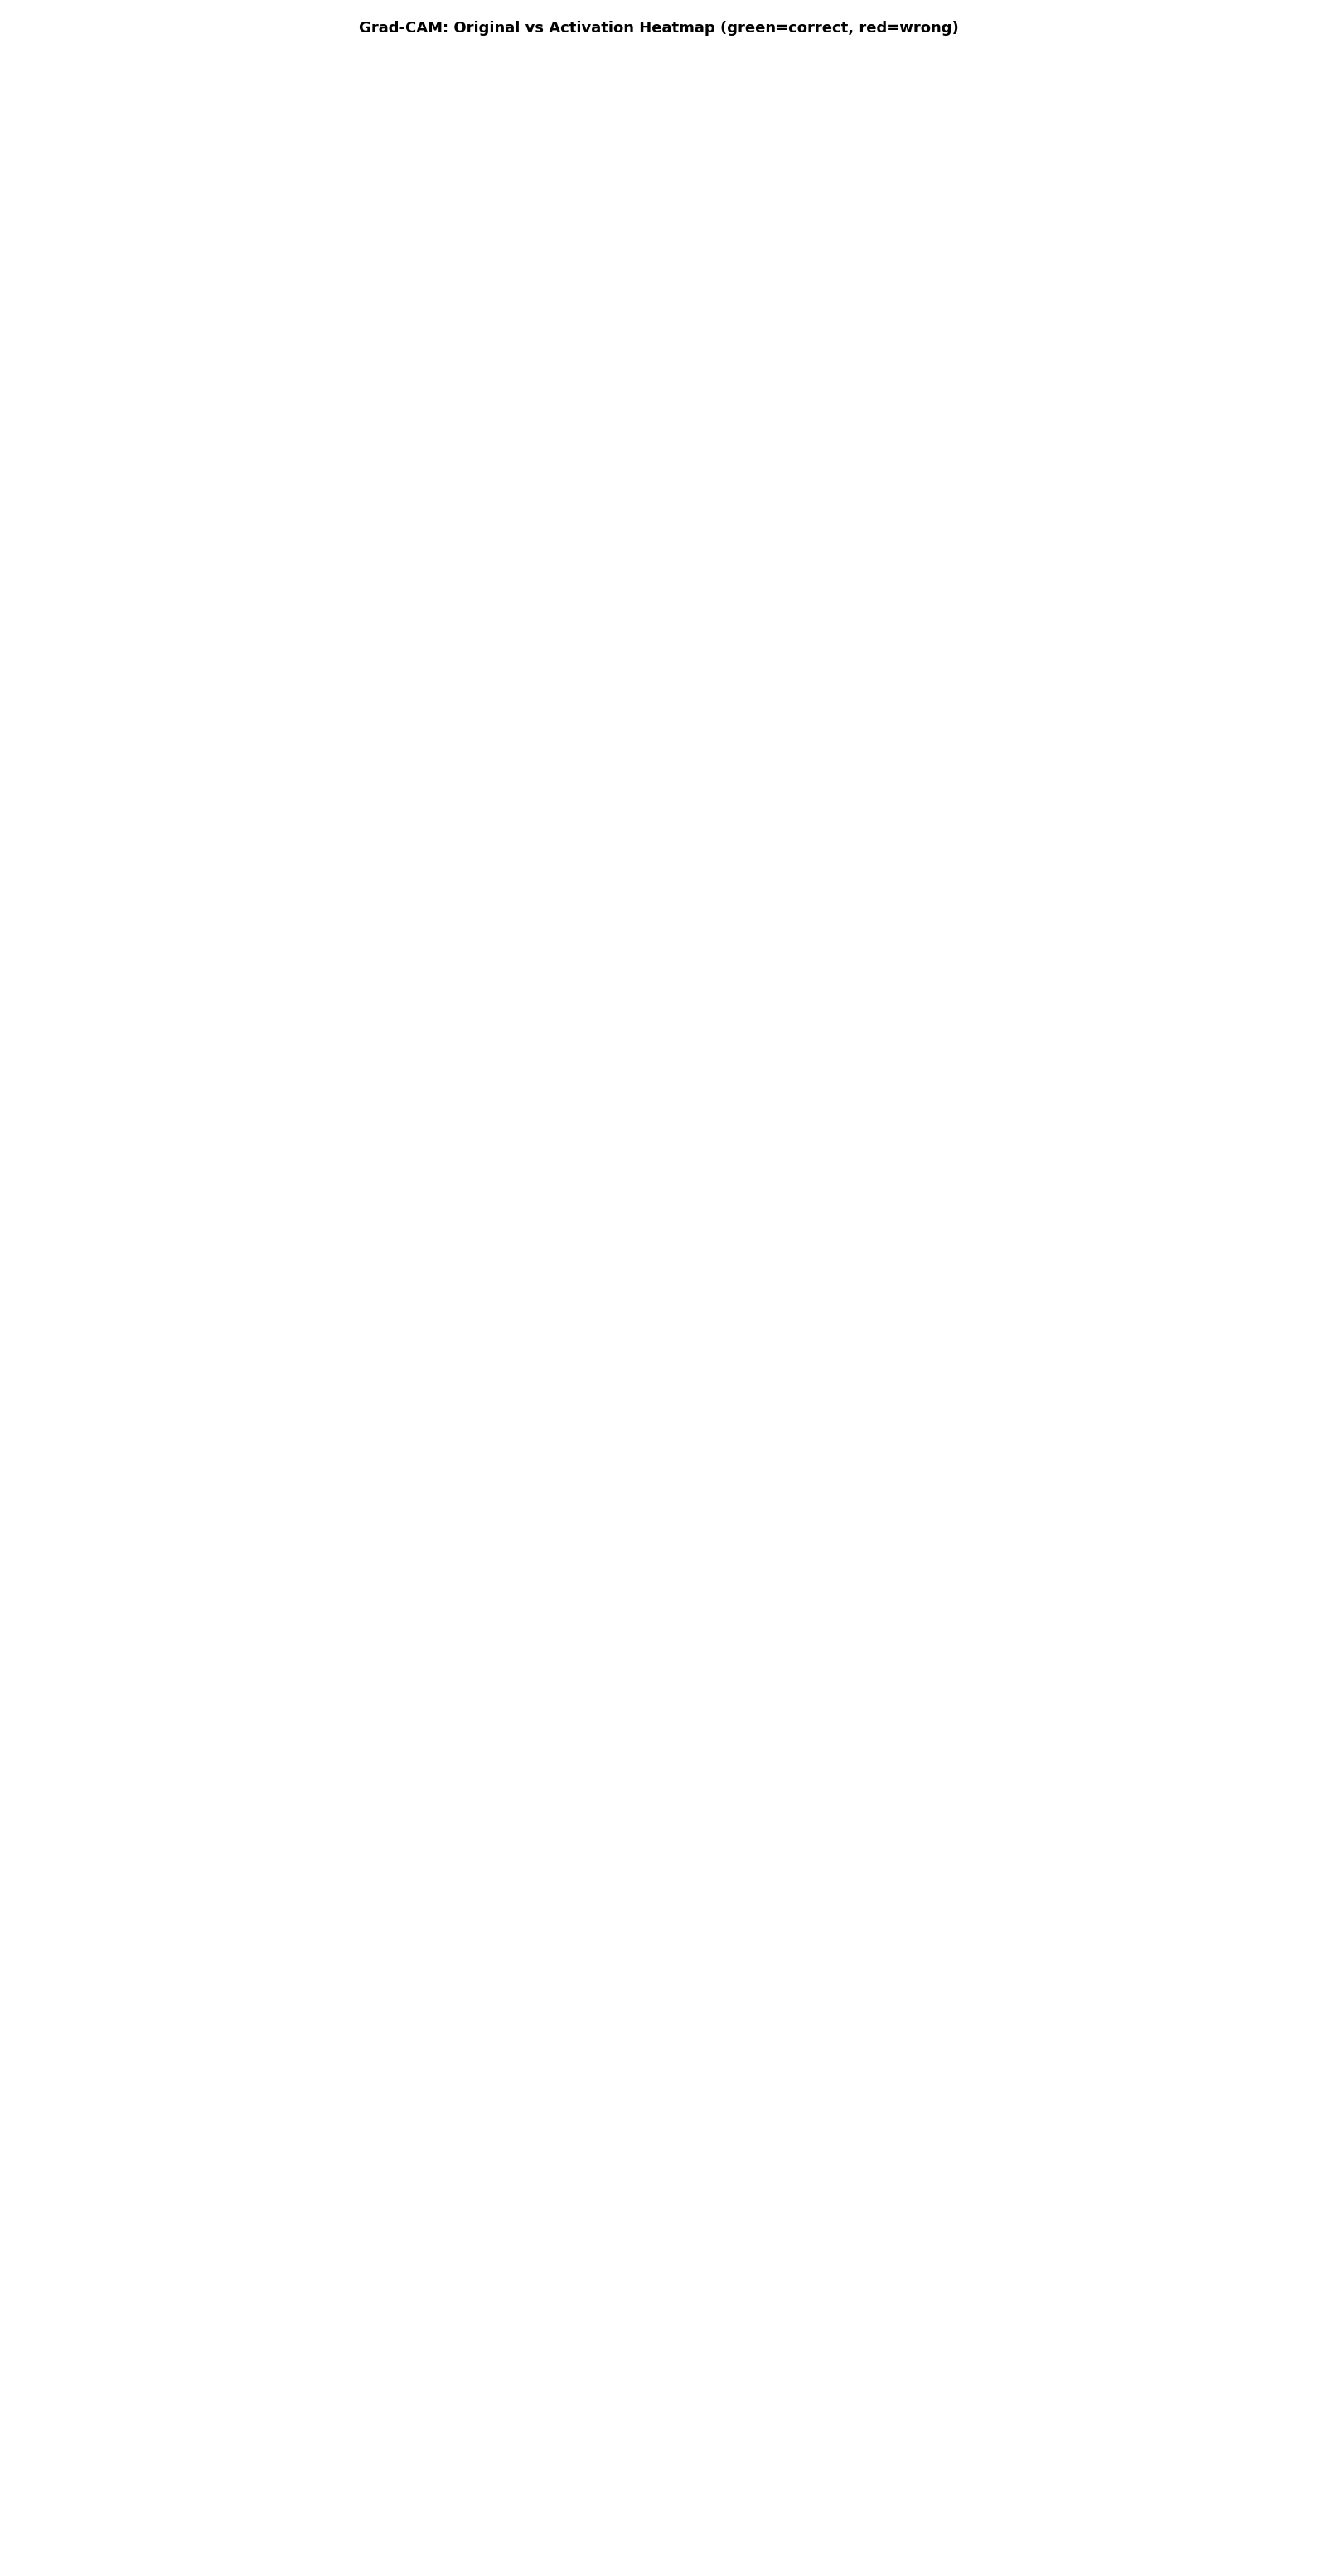

Grad-CAM saved -> output/gradcam/gradcam_results.png


In [18]:
# Show Grad-CAM for 2 samples per class
N_SHOW = 2
fig, axes = plt.subplots(NUM_CLASSES, N_SHOW * 2, figsize=(4 * N_SHOW * 2, 3.5 * NUM_CLASSES))

for row, class_name in enumerate(sorted(CLASS_NAMES)):
    class_idx = le.transform([class_name])[0]
    subset    = df_test[df_test["label"] == class_name]
    samples   = subset.sample(min(N_SHOW, len(subset)), random_state=RANDOM_STATE)

    for col_pair, (_, sample) in enumerate(samples.iterrows()):
        path = sample["image_path"]
        img_array = load_and_preprocess(path, augment=False)
        img_tensor = np.expand_dims(img_array, axis=0)

        try:
            heatmap, preds = make_gradcam_heatmap(img_tensor, best_model, last_conv_layer)
            pred_label = le.inverse_transform([np.argmax(preds[0])])[0]
            original, overlay = overlay_gradcam(path, heatmap)

            col_orig    = col_pair * 2
            col_overlay = col_pair * 2 + 1

            axes[row, col_orig].imshow(original)
            axes[row, col_orig].axis("off")
            if col_pair == 0:
                axes[row, col_orig].set_ylabel(class_name, fontsize=9, fontweight="bold")

            correct = pred_label == class_name
            color   = "#2ecc71" if correct else "#e74c3c"
            axes[row, col_overlay].imshow(overlay)
            axes[row, col_overlay].axis("off")
            axes[row, col_overlay].set_title(
                f"Pred: {pred_label}", fontsize=8,
                color=color, fontweight="bold"
            )
        except Exception as e:
            axes[row, col_pair * 2].axis("off")
            axes[row, col_pair * 2 + 1].axis("off")

plt.suptitle("Grad-CAM: Original vs Activation Heatmap (green=correct, red=wrong)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/gradcam/gradcam_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("Grad-CAM saved -> output/gradcam/gradcam_results.png")

## 🍎🍊🍌 17. Per-Fruit & Per-Grade Accuracy Breakdown

Class           Correct    Total   Accuracy
--------------------------------------------
apple_A             100      100    100.0%  ████████████████████
apple_B              93      116     80.2%  ████████████████
apple_C              83       97     85.6%  █████████████████
banana_A             83       83    100.0%  ████████████████████
banana_B            151      165     91.5%  ██████████████████
banana_C             44       47     93.6%  ██████████████████
orange_A             84       84    100.0%  ████████████████████
orange_B            148      176     84.1%  ████████████████
orange_C             16       18     88.9%  █████████████████


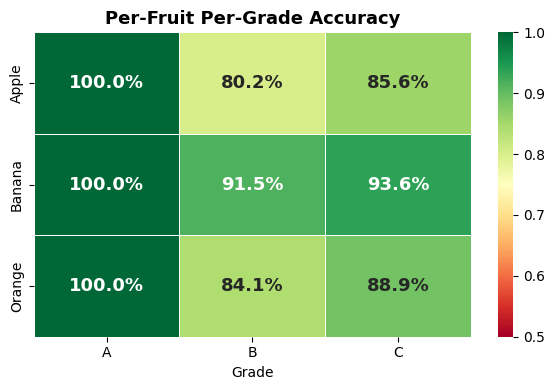

In [19]:
results = []
for class_name in sorted(CLASS_NAMES):
    class_idx  = le.transform([class_name])[0]
    mask       = (y_true == class_idx)
    if mask.sum() == 0:
        continue
    correct    = (y_pred[mask] == class_idx).sum()
    total      = mask.sum()
    fruit, grade = class_name.split("_")
    results.append({
        "Class":    class_name,
        "Fruit":    fruit.capitalize(),
        "Grade":    grade,
        "Correct":  correct,
        "Total":    total,
        "Accuracy": correct / total,
    })

df_results = pd.DataFrame(results)

# Display as styled table
print(f"{'Class':<14} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print("-" * 44)
for _, row in df_results.iterrows():
    bar = chr(9608) * int(row["Accuracy"] * 20)
    print(f"{row['Class']:<14} {int(row['Correct']):>8} {int(row['Total']):>8} {row['Accuracy']:>9.1%}  {bar}")

# Heatmap
pivot = df_results.pivot(index="Fruit", columns="Grade", values="Accuracy")
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn",
            vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5,
            annot_kws={"size": 13, "fontweight": "bold"})
ax.set_title("Per-Fruit Per-Grade Accuracy", fontsize=13, fontweight="bold")
ax.set_xlabel("Grade")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## 🔮 18. Predict a Single Image

Use this cell to grade any new fruit image.

Image      : rotated_by_15_Screen Shot 2018-06-13 at 12.02.53 AM.png
Fruit      : Orange
Grade      : A (Premium quality)
Confidence : 67.70%

Top 3 predictions:
  1. orange_A       67.70%
  2. orange_B       14.46%
  3. orange_C       13.74%


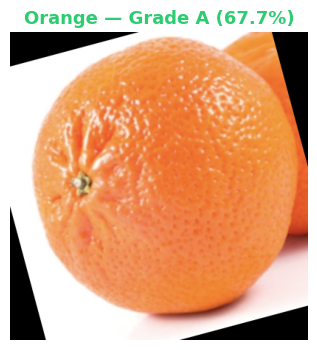

('orange_A', 0.67700684)

In [20]:
def predict_fruit_grade(image_path: str, model, label_encoder):
    """Predict the fruit type and quality grade for a single image."""
    img = load_and_preprocess(image_path, augment=False)
    img_tensor = np.expand_dims(img, axis=0)

    preds      = model.predict(img_tensor, verbose=0)[0]
    pred_idx   = np.argmax(preds)
    pred_label = label_encoder.inverse_transform([pred_idx])[0]
    confidence = preds[pred_idx]

    fruit, grade = pred_label.split("_")
    grade_desc   = {"A": "Premium", "B": "Average", "C": "Low"}

    print(f"Image      : {Path(image_path).name}")
    print(f"Fruit      : {fruit.capitalize()}")
    print(f"Grade      : {grade} ({grade_desc[grade]} quality)")
    print(f"Confidence : {confidence:.2%}")
    print("\nTop 3 predictions:")
    top3 = np.argsort(preds)[::-1][:3]
    for i, idx in enumerate(top3):
        label = label_encoder.inverse_transform([idx])[0]
        print(f"  {i+1}. {label:<14} {preds[idx]:.2%}")

    # Show image
    img_display = cv2.imread(image_path)
    img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4, 4))
    plt.imshow(img_display)
    plt.axis("off")
    plt.title(f"{fruit.capitalize()} — Grade {grade} ({confidence:.1%})",
              fontsize=13, fontweight="bold",
              color={"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c"}[grade])
    plt.show()

    return pred_label, confidence


# ── Example usage ──
# Replace with any image path from your dataset or a new image
sample_path = df_test.sample(1, random_state=99)["image_path"].values[0]
predict_fruit_grade(sample_path, best_model, le)

## 💾 19. Save Final Model & Summary

In [21]:
# Save model in SavedModel format as well
best_model.save(f"{MODEL_DIR}/fruit_grader_final.keras")

# Save label encoder classes
np.save(f"{MODEL_DIR}/class_names.npy", le.classes_)

print("=" * 55)
print("  STEP 2 COMPLETE — CNN Training")
print("=" * 55)
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  F1-Score      : {f1:.4f}  (macro)")
print("")
print("  Saved files:")
print(f"    {MODEL_DIR}/fruit_grader.keras")
print(f"    {MODEL_DIR}/fruit_grader_final.keras")
print(f"    {MODEL_DIR}/class_names.npy")
print(f"    {OUTPUT_DIR}/plots/training_curves.png")
print(f"    {OUTPUT_DIR}/plots/confusion_matrix.png")
print(f"    {OUTPUT_DIR}/plots/per_class_accuracy.png")
print(f"    {OUTPUT_DIR}/gradcam/gradcam_results.png")
print(f"    {OUTPUT_DIR}/classification_report.txt")
print("")
print("  Next: Step 3 - Streamlit Demo App")

  STEP 2 COMPLETE — CNN Training
  Test Accuracy : 0.9052  (90.52%)
  F1-Score      : 0.8927  (macro)

  Saved files:
    output/models/fruit_grader.keras
    output/models/fruit_grader_final.keras
    output/models/class_names.npy
    output/plots/training_curves.png
    output/plots/confusion_matrix.png
    output/plots/per_class_accuracy.png
    output/gradcam/gradcam_results.png
    output/classification_report.txt

  Next: Step 3 - Streamlit Demo App
